In [11]:
import torch
import json
import cv2
import os
import einops as eps
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from dataset.InterHand26M.utils.mano import mano

Fix shapedirs bug of MANO


In [12]:
fh_root = "./data/freihand/"

In [13]:
ix = 3004

img_path = os.path.join(fh_root, "training", "rgb", f"{ix:08d}.jpg")
img = cv2.imread(img_path)
img = img[:,:,::-1]

In [14]:
with open(os.path.join(fh_root, "training_K.json"), "r") as f:
    training_K = json.load(f)
with open(os.path.join(fh_root, "training_xyz.json"), "r") as f:
    training_xyz = json.load(f)
with open(os.path.join(fh_root, "training_mano.json"), "r") as f:
    training_mano = json.load(f)

training_K = np.array(training_K)
training_xyz = np.array(training_xyz)
training_mano = np.array(training_mano, dtype=np.float32)

In [26]:
torch.sin(torch.tensor(3.1415926))

tensor(1.5100e-07)

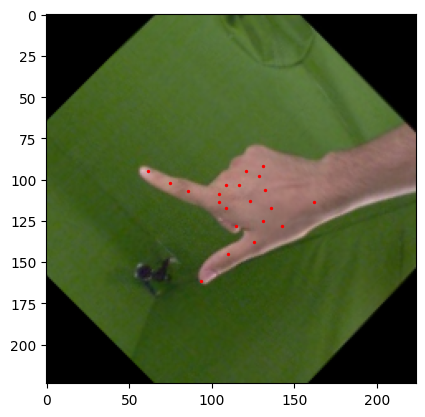

In [49]:
import kornia

kps3d = training_xyz[ix]
intr = training_K[ix]
mano_data = training_mano[ix]

rot_deg = torch.tensor([torch.pi / 4])  # torch.rand(size=(1,)) * torch.pi * 2
rot_ang = rot_deg * 180 / torch.pi

rot_mat = torch.Tensor([
    [torch.cos(-rot_deg), -torch.sin(-rot_deg), 0],
    [torch.sin(-rot_deg), torch.cos(-rot_deg), 0],
    [0, 0, 1]
])
kps3d = (rot_mat @ kps3d.T).T
kps2d = intr.dot(kps3d.T).T
kps2d = kps2d[..., :-1] / kps2d[..., -1:]

img_tensor = torch.from_numpy(img.copy()).permute(2,0,1)[None,...] / 255.
img_tensor = kornia.geometry.transform.rotate(img_tensor, rot_ang)[0]

plt.imshow(img_tensor.permute(1,2,0))
plt.scatter(kps2d[:,0], kps2d[:,1], c='r', s=2)

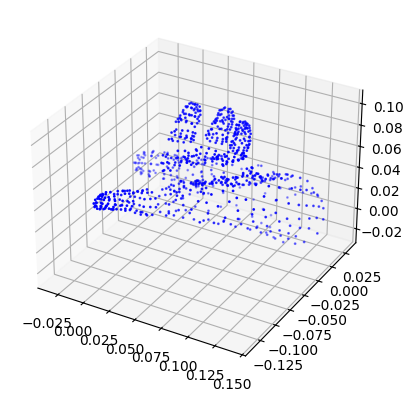

In [68]:
%matplotlib inline

pose, shape, uv_root, scale = eps.unpack(mano_data, [(48,), (10,), (2,), (1,)], "d *")
r_output = mano.layer['right'](betas=torch.from_numpy(shape),
                               hand_pose=torch.from_numpy(pose[:,3:]),
                               global_orient=torch.from_numpy(pose[:,:3]),
                               transl=torch.zeros(1, 3))

v3d = r_output.vertices[0].numpy()

fig3d = plt.figure(3)
ax3d = fig3d.add_subplot(111, projection='3d')
ax3d.scatter(v3d[:,0], v3d[:,1], v3d[:,2], c='b', s=1)

plt.show()

In [73]:
import kornia

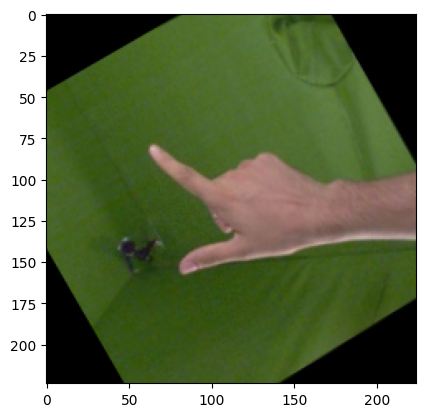

In [81]:
img_tensor = torch.from_numpy(img.copy()) / 255.
rotated_img_tensor = kornia.geometry.transform.rotate(eps.rearrange(img_tensor, "h w c -> c h w")[None,...], torch.Tensor([30.]))
rotated_img_tensor = eps.rearrange(rotated_img_tensor[0], 'c h w -> h w c')
plt.imshow(rotated_img_tensor)

# dataset

In [1]:
from dataset import FreiHand
import matplotlib.pyplot as plt

/home/renkaiwen/.conda/envs/sl_vit_cu118/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
fh_dataset = FreiHand(mode="train")

In [10]:
item = fh_dataset[399]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0400882..2.2672744].


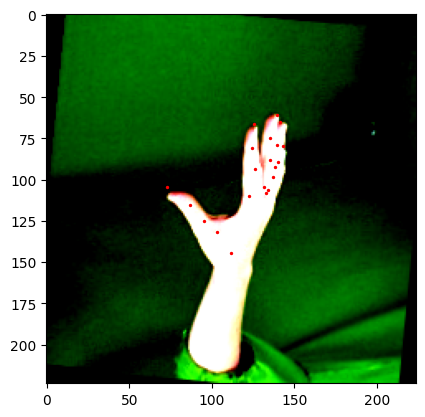

In [11]:
intr = item["K"]
kps3d = item["joints_3d"]

kps2d = (intr @ kps3d.T).T
kps2d = kps2d[..., :-1] / kps2d[..., -1:]

plt.imshow(item['image'].permute(1,2,0))
plt.scatter(kps2d[:,0], kps2d[:,1], c='r', s=2)